### Computation of the Eigenvalue line

In [27]:
import numpy as np
from scipy.optimize import minimize_scalar

# Define H1d(k)
DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

def H1d(k):
    return 2 * np.sin(k) / k if k != 0 else 2.0  # handle k=0 safely


#def Trace
def trace_aq(k,mu):
    return - D_r -2 *k**2 - (mu * H1d(k)) / 2
def det_aq(k,mu,Pe):
    return 0.5 * k**2 * Pe**2 + (-D_r - k**2) * (-k**2 - mu * H1d(k) /2 )


# Define Lambda_nf1d(mu, k, Pe)
def Lambda_nf1d(mu, k, Pe):
    return -(k**2 + 0.5 * Pe**2 * (k**2 / (k**2 + D_r)) + (mu * H1d(k)) / 2)

# Range of Pe values
Pe_values = np.arange(0, 10,0.1)  # from 0 to 1 in steps of 0.1

results = []

for Pe in Pe_values:
    mus = np.arange(40, 800.1, 0.1)
    Lkc = []

    # For each mu, find the maximum of Lambda_nf1d(mu, k, Pe) for k in (1, 20)
    for mu in mus:
        res = minimize_scalar(lambda k: -Lambda_nf1d(mu, k, Pe), bounds=(1, 10), method='bounded')
        Lkc.append(-res.fun)  # negate back since we minimized the negative

    Lkc = np.array(Lkc)

    # Find the first mu where Lkc > 0
    positive_indices = np.where(Lkc > 0)[0]
    if len(positive_indices) > 0:
        mu_c = mus[positive_indices[0]]
    else:
        mu_c = np.nan  # if none positive, assign NaN

    results.append((Pe, mu_c))

# Display results
for Pe, mu_c in results:
    print(f"Pe = {Pe:.2f}, mu_c = {mu_c:.3f}")
np.savetxt("../Figures/results.txt", results, header="Pe  mu_c", fmt="%.4f")

Pe = 0.00, mu_c = 84.200
Pe = 0.10, mu_c = 84.300
Pe = 0.20, mu_c = 84.300
Pe = 0.30, mu_c = 84.500
Pe = 0.40, mu_c = 84.600
Pe = 0.50, mu_c = 84.900
Pe = 0.60, mu_c = 85.100
Pe = 0.70, mu_c = 85.400
Pe = 0.80, mu_c = 85.800
Pe = 0.90, mu_c = 86.200
Pe = 1.00, mu_c = 86.700
Pe = 1.10, mu_c = 87.200
Pe = 1.20, mu_c = 87.700
Pe = 1.30, mu_c = 88.300
Pe = 1.40, mu_c = 89.000
Pe = 1.50, mu_c = 89.700
Pe = 1.60, mu_c = 90.400
Pe = 1.70, mu_c = 91.200
Pe = 1.80, mu_c = 92.100
Pe = 1.90, mu_c = 93.000
Pe = 2.00, mu_c = 93.900
Pe = 2.10, mu_c = 94.900
Pe = 2.20, mu_c = 95.900
Pe = 2.30, mu_c = 97.000
Pe = 2.40, mu_c = 98.100
Pe = 2.50, mu_c = 99.300
Pe = 2.60, mu_c = 100.500
Pe = 2.70, mu_c = 101.700
Pe = 2.80, mu_c = 103.000
Pe = 2.90, mu_c = 104.400
Pe = 3.00, mu_c = 105.800
Pe = 3.10, mu_c = 107.200
Pe = 3.20, mu_c = 108.700
Pe = 3.30, mu_c = 110.200
Pe = 3.40, mu_c = 111.800
Pe = 3.50, mu_c = 113.400
Pe = 3.60, mu_c = 115.100
Pe = 3.70, mu_c = 116.800
Pe = 3.80, mu_c = 118.600
Pe = 3.90, m

### Computation of critical Mu

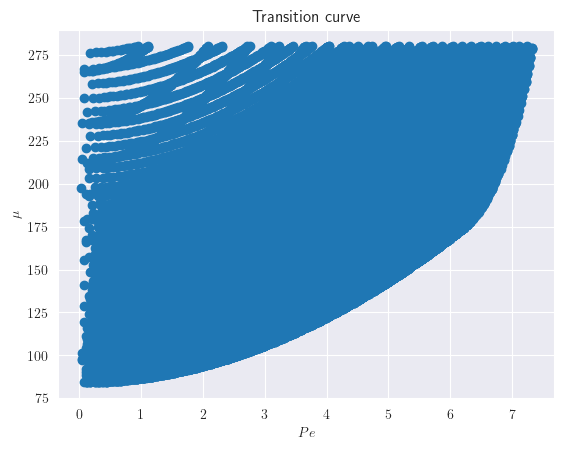

In [26]:
import numpy as np
from scipy.optimize import minimize_scalar
# Define H1d(k)
DIFF_T = 1.5e-5
COMP_RADIUS = 0.1
DIFF_R =0.001
TAU = COMP_RADIUS**2 / DIFF_T
D_r = DIFF_R* TAU

def H1d(k):
    return 2 * np.sin(k) / k if k != 0 else 2.0  # handle k=0 safely


#def Trace
def trace_aq(k,mu):
    return - D_r -2 *k**2 - (mu * H1d(k)) / 2
def det_aq(k,mu,Pe):
    return 0.5 * k**2 * Pe**2 + (-D_r - k**2) * (-k**2 - mu * H1d(k) /2 )


# Define Lambda_nf1d(mu, k, Pe)
def Lambda_nf1d(mu, k, Pe):
    return -(k**2 + 0.5 * Pe**2 * (k**2 / (k**2 + D_r)) + (mu * H1d(k)) / 2)



k_values  = np.linspace(0.1, 10.0, 500)     # avoid k=0
mu_values = np.linspace(70, 280.0, 1000)
Pe_values = np.linspace(0.0, 10, 400)


transition_points = []

def mu_critical(k):
    return -2*(D_r + 2*k**2)/H1d(k)


transition_curve = []

for k in k_values:
    mu_max = mu_critical(k)
    for mu in mu_values[mu_values < mu_max]:
        det_vals = det_aq(k, mu, Pe_values)
        idx = np.where(np.diff(np.sign(det_vals)))[0]
        if len(idx):
            transition_curve.append((k, mu, Pe_values[idx[0]]))




import matplotlib.pyplot as plt

# unpack last two entries (mu, Pe)
mu_vals = [t[-2] for t in transition_curve]
Pe_vals = [t[-1] for t in transition_curve]

plt.figure()
plt.plot(Pe_vals,mu_vals, 'o')
plt.ylabel(r'$\mu$')
plt.xlabel(r'$Pe$')
plt.title('Transition curve')
plt.show()

# Stack columns: Pe   mu
data = np.column_stack((Pe_vals, mu_vals))

# Save to text file
np.savetxt(
    "../Figures/transition_curve_all.txt",
    data,
    header="Pe    mu",
    fmt="%.6e"
)

### DATA analysis of 1d Data

Group: FIELD_DATA
Dataset: FIELD_DATA/PX_0, Shape: (512,), Dtype: float16
Dataset: FIELD_DATA/PX_F, Shape: (512,), Dtype: float32
Dataset: FIELD_DATA/RHO_0, Shape: (512,), Dtype: float16
Dataset: FIELD_DATA/RHO_F, Shape: (512,), Dtype: float32
Group: metadata
Dataset: metadata/ADMENSIONAL_DR, Shape: (1,), Dtype: float16
Dataset: metadata/BIRTH_RATE, Shape: (1,), Dtype: float32
Dataset: metadata/DENSITY_SERIES, Shape: (1, 4001), Dtype: float32
Dataset: metadata/DIFF_R, Shape: (1,), Dtype: float16
Dataset: metadata/DIFF_T, Shape: (1,), Dtype: float16
Dataset: metadata/L, Shape: (1,), Dtype: float32
Dataset: metadata/NET_GROWTH_RATE, Shape: (1,), Dtype: float16
Dataset: metadata/PECLET, Shape: (1,), Dtype: float16
Dataset: metadata/POLARIZATION_INTEGRAL_SERIES, Shape: (1, 4001), Dtype: float32
Dataset: metadata/POLARIZATION_SERIES, Shape: (1, 4001), Dtype: float32
Dataset: metadata/RADIUS_KERNEL, Shape: (1,), Dtype: float16
Dataset: metadata/SIUMULATION_TIME, Shape: (1,), Dtype: float32
D

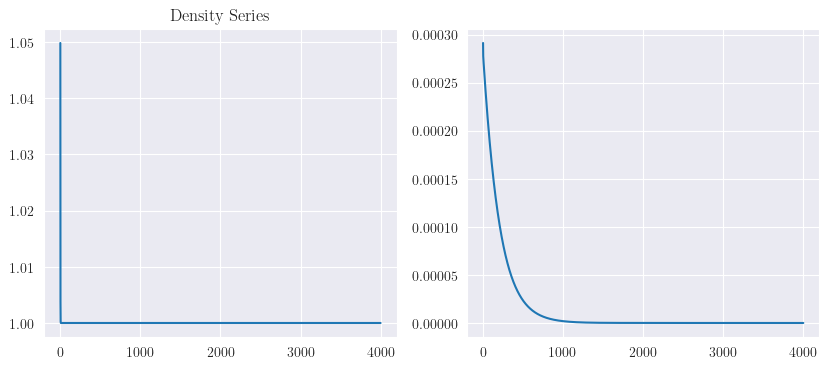

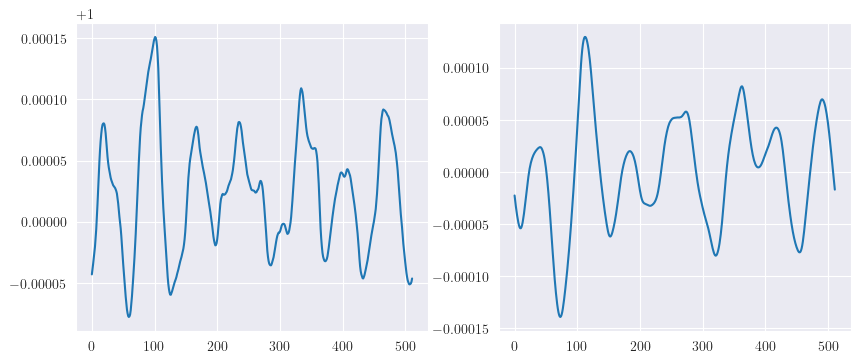

In [29]:
import h5py
import os, sys, re
from tqdm import tqdm
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib import rc

# Choose the font for the figure
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

### HDF5 File Inspection
def print_name(name, obj):
    """Function to print the name of groups and datasets in an HDF5 file."""
    if isinstance(obj, h5py.Group):
        print(f"Group: {name}")
    elif isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name}, Shape: {obj.shape}, Dtype: {obj.dtype}")


def print_hdf5_contents(file_path):
    """Function to open an HDF5 file and print its contents."""
    with h5py.File(file_path, 'r') as f:
        f.visititems(print_name)



mu , pe = 170.0, 9.1
file_path = f'../Data/1d_v1/_PE{pe:.2f}_MU{mu:.2f}/DATA.h5'








with h5py.File(file_path, 'r') as f:
    print_hdf5_contents(file_path)


    meta = f['FIELD_DATA']
    rhodata = meta['RHO_F'][:]
    pol = meta['PX_F'][:]


    meta2 = f['metadata']



    op = meta2['POLARIZATION_INTEGRAL_SERIES'][:].flatten()
    density = meta2['DENSITY_SERIES'][:].flatten()

    fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    ax1.plot(density)
    ax2.plot(op)
    ax1.set_title('Density Series')
    # ax2.set_title('Fourier Series')
    plt.show()
    plt.close()
    # fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    # ax1.plot(op_wei)
    # ax2.plot(op)
    # ax1.set_title('Polarization Weighted Density Series')
    # ax2.set_title('Polarization Series')
    # plt.show()
    # plt.close()
    #
    fig , (ax1,ax2) = plt.subplots(1,2, figsize = (10,4))
    ax1.plot(rhodata)
    ax2.plot(pol)
    plt.show()

